# Non-negative Matrix Factorization (NMF)

NMF is a dimension reduction technique that is particularly useful when dealing with sparse data.
Data must be non-negative!

> Note: A NMF is easy to interpret, easy to explain!

tf-idf is a great way to transform text into a meaningful representation of numbers.
"tf" = term frequency
"idf" = inverse document frequency

In [12]:
import kaggle

# Download a Kaggle dataset
kaggle.api.dataset_download_files('datatattle/covid-19-nlp-text-classification', path='./', unzip=True)

In [13]:
import pandas as pd

df = pd.read_csv('Corona_NLP_train.csv', encoding='ISO-8859-1')
print(df.head())

   UserName  ScreenName   Location     TweetAt  \
0      3799       48751     London  16-03-2020   
1      3800       48752         UK  16-03-2020   
2      3801       48753  Vagabonds  16-03-2020   
3      3802       48754        NaN  16-03-2020   
4      3803       48755        NaN  16-03-2020   

                                       OriginalTweet           Sentiment  
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...             Neutral  
1  advice Talk to your neighbours family to excha...            Positive  
2  Coronavirus Australia: Woolworths to give elde...            Positive  
3  My food stock is not the only one which is emp...            Positive  
4  Me, ready to go at supermarket during the #COV...  Extremely Negative  


In [14]:
print(df.shape)
print(df.columns)

(41157, 6)
Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')


## NMF rocks interpretable topics

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

countVectorizer = CountVectorizer(stop_words='english', max_df=0.95, min_df=0.05, max_features=1000)
countVector = countVectorizer.fit_transform(df['OriginalTweet'])

print(countVector.shape)

(41157, 26)


In [16]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=10)
nmf.fit(countVector)

print(nmf.components_.shape)

(10, 26)


In [17]:
# Visualize an random example
import matplotlib.pyplot as plt

bitmap = nmf.components_[0].reshape(2, 13)
print(bitmap)

[[ 0.          0.          5.42265354  0.          0.10376519  3.07907709
   1.10020238  1.16835946  0.          0.          0.34978063 59.95442913
   0.        ]
 [ 0.          0.          0.          2.09454584  0.          0.
   0.          0.          0.          0.          0.          0.51197328
   0.        ]]


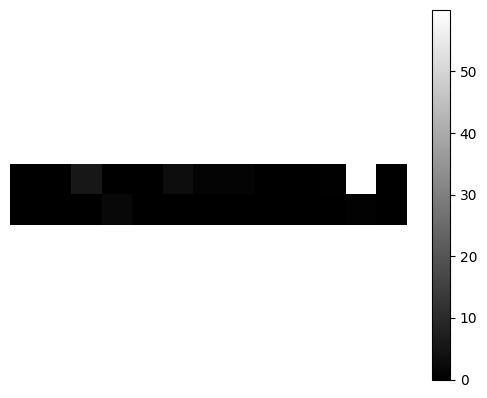

In [19]:
plt.imshow(bitmap, cmap='gray', interpolation='nearest')
plt.axis('off')
plt.colorbar()
plt.show()

In [ ]:
# select the first row
first = nmf.components_[0]